# IMDB reviews classification in Keras (RNN, LSTM, GRU, Bidirectional, Stacked (Deep))

The task is to experiment with different architectures (RNN, LSTM, GRU, Bidirectional, Stacked (Deep)), compare, draw conclusions. Rules that are being followed for a fair comparison:
- fixed vocab, maxlen, embedding dim, batch size and unit count across every run. The only difference between runs is the architecture.
- we adjust the number of neurons (hidden size) with respect to the architecture to keep the final number of parameters roughly the same

## Libraries and constants

In [1]:
import gc
import os

import seaborn as sns

os.environ["KERAS_BACKEND"] = "torch"
import functools

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from utils import plot_loss_acc_per_ep, seed_everything, debug_tuner

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Data Import, Overview, EDA, Cleaning

### Choosing VOCAB_SIZE

The task and lectures tell nothing again, we have to figure everything out ourselves. Since we don't have full raw text (and it's not NLP anyway, RNNs are largely replaced by transformers these days), I don't see any point in this search. For a real case, I would divide into tokens, count unique and sorted descending. As soon as vocabulary count start occurring only a handful of times, we truncate it. Let's imagine it happened at the value of $10,000$ here since everyone likes to stick to this size so much.

In general, `VOCAB_SIZE`, `MAX_LENGTH` and `EMBED_DIM` are not hyperparameters to be tuned during training in the same way as we do with learning rate, optimizer or epochs. They are compute knobs in the sense that raising them helps, then stops helping, then costs a lot of time and a little overfitting. We are going to choose them moderately (to be on the more optimal size), but realistically and only try to increase if the model underfits (hardly be the case for such a simple task I suppose).

`MAX_LENGTH` and `VOCAB_SIZE` are both truncation - we're deciding how much of the input to throw away. Same rule for both: keep roughly 90–95% of the content.

`EMBED_DIM` isn't truncation, it's capacity, so it saturates for a different reason: at some point extra dimensions have no more structure to encode. The rule: pick from the standard ladder (32/64/128/256) and only revisit if the model is underfitting.

In [3]:
VOCAB_SIZE = 10_000     # keep the 10k most frequent words; the rest become <OOV>

In [4]:
# ---------- 1. Load and pad ----------
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

### Data overview

In [5]:
x_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [6]:
print(f"Train targets: {np.unique(y_train)}")
print(f"Test targets: {np.unique(y_test)}")

Train targets: [0 1]
Test targets: [0 1]


The dataset is also pre-encoded, which isn't great for learning again. Not able to derive the method and try it ourselves. The research on how it's done in this dataset is below.

The text was already stripped off of any punctuation (because the dataset is very old and deleting punctuation was a cheap fix for speed) and lowercased. Then the most frequent words are determined and sorted, each word is represented via that popularity number PLUS 3 - reserved for the special tokens:
- "1" marks the start of a sequence (of a review in this case)
- "2" marks OOV words
- "0" isn't present for now, but reserved for padding

According to the docs, the target is binary, where:
- $0$ stands for negative review
- $1$ stands for positive review

### Class balance

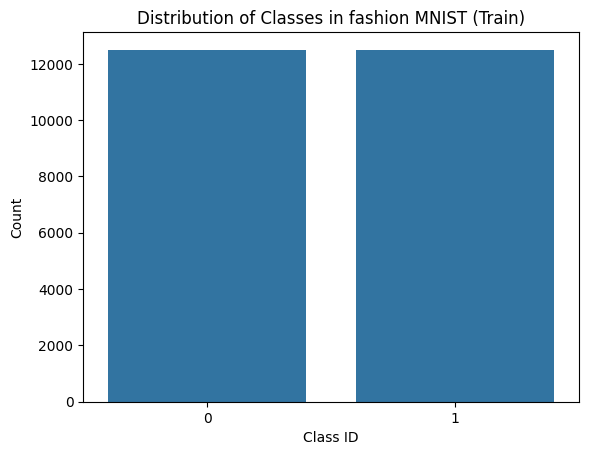

In [7]:
sns.countplot(x=y_train)
plt.title("Distribution of Classes in fashion MNIST (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [8]:
np.unique(y_train, return_counts=True)

(array([0, 1], dtype=int64), array([12500, 12500], dtype=int64))

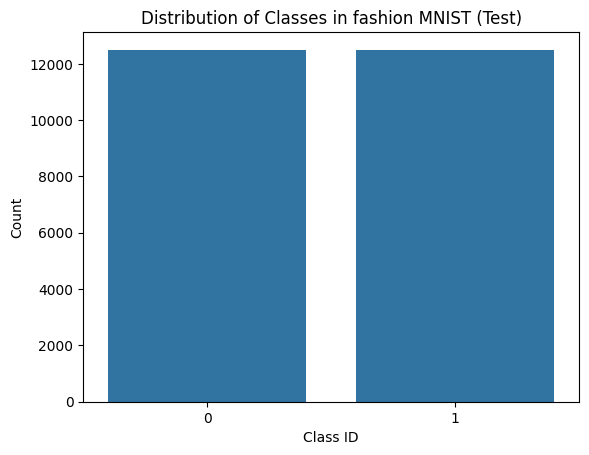

In [9]:
sns.countplot(x=y_test)
plt.title("Distribution of Classes in fashion MNIST (Test)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [10]:
np.unique(y_test, return_counts=True)

(array([0, 1], dtype=int64), array([12500, 12500], dtype=int64))

The split is perfectly stratified by the target. Balanced.

### Data split

In [11]:
print(f"Reviews in train: {x_train.shape}")
print(f"Reviews in test: {x_test.shape}")

Reviews in train: (25000,)
Reviews in test: (25000,)


The ratio of the supplied split is 50/50. It is weird and doesn't reflect modern practices. Resplitting into 80/20:

In [12]:
# Combine all train and test Xs and ys
x_full = np.concatenate([x_train, x_test])
y_full = np.concatenate([y_train, y_test])

# 80/20 split into train and temp (that will be divided further), stratified by target
x_train, x_temp, y_train, y_temp = train_test_split(
    x_full,
    y_full,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_full,
)

# 50/50 split of temp into validation and test, stratified by target
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

print("Train size:", len(x_train))
print("Val size:", len(x_val))
print("Test size:", len(x_test))

print()

print("Class balance in train:", np.unique(y_train, return_counts=True))
print("Class balance in validation:", np.unique(y_val, return_counts=True))
print("Class balance in test:", np.unique(y_test, return_counts=True))

Train size: 40000
Val size: 5000
Test size: 5000

Class balance in train: (array([0, 1], dtype=int64), array([20000, 20000], dtype=int64))
Class balance in validation: (array([0, 1], dtype=int64), array([2500, 2500], dtype=int64))
Class balance in test: (array([0, 1], dtype=int64), array([2500, 2500], dtype=int64))


### Choosing MAX_LENGTH

As mentioned in the "Choosing VOCAB_SIZE" section, it is recommended to take the 95th percentile of the data as MAX_LENGTH. However, skewness of the distribution must be taken into account.

In [13]:
train_sequence_lengths = [len(seq) for seq in x_train]
recommended_maxlen = int(np.percentile(train_sequence_lengths, 95))
print(f"Average length: {np.mean(train_sequence_lengths):.1f}")
print(f"95th percentile maxlen: {recommended_maxlen}")

Average length: 235.1
95th percentile maxlen: 598


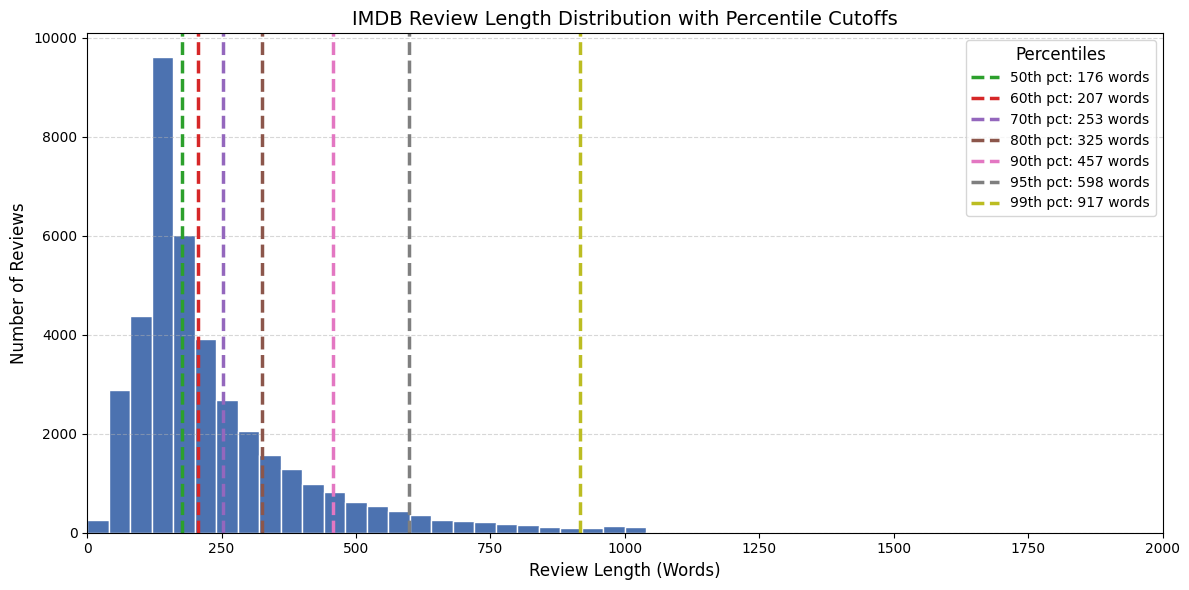

In [14]:
# Convert to numpy array
lengths = np.array(train_sequence_lengths)

plt.figure(figsize=(12, 6))

# cutting off at 2000 for visual clarity on the x-axis
max_x = 2000

# Plot the distribution
plt.hist(
    lengths,
    bins=50,
    range=(0, max_x),
    color="#4C72B0",
    edgecolor="white",
)

# The percentiles to track
percentiles = [50, 60, 70, 80, 90, 95, 99]

# A readable color palette for the vertical lines
colors = ["#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

# Plot a vertical line for each percentile
for p, color in zip(percentiles, colors, strict=False):
    val = np.percentile(lengths, p)
    plt.axvline(
        val,
        color=color,
        linestyle="--",
        linewidth=2.5,
        label=f"{p}th pct: {int(val)} words",
    )

# Formatting
plt.title("IMDB Review Length Distribution with Percentile Cutoffs", fontsize=14)
plt.xlabel("Review Length (Words)", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xlim(0, max_x)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Place the legend cleanly outside or in the upper right
plt.legend(title="Percentiles", fontsize=10, title_fontsize=12, loc="upper right")
plt.tight_layout()

plt.show()

The distribution is right skewed, 95th percentile is too many. I would base my guess at the 80th (325 words). To round and stay more optima: 300 words.

In [15]:
MAX_LENGTH = 300 # max length of a sequence

### Padding and Truncating

To make the batches of the same size (to make matrix multiplication operations possible by having rectangular matrices), we pad the sequences that are too short with $0$s until they reach `MAX_LENGTH`.

We also choose `padding="pre"` following the industry standard but it essentially doesn't matter since we're going to use `mask_zeroes="True"` anyway.

For `truncating="pre"`, it is also a standard because most of the context opens towards the end of the delivery. For example, beginning: "I went to see this movie on a Tuesday with my friends. The theater was cold. The director is known for his previous work on...", the end: "...but none of that mattered because the acting was terrible and the plot made no sense. Overall, a complete waste of time. I hated it.".

**NOTE**: `mask_zero` in an `Embedding` layer ignores $0$s regardless of what type of `padding` we use, *BUT* (and it comes from LSTM's docstring in Keras): cuDNN fast path *on PyTorch back-end* requires **`keras.Embedding(mask_zero=False))`**. Therefore, we have to use **pre-padding** then with `mask_zero` set to `False` to keep the fast GPU.

In [ ]:
# 0=<PAD>, 1=<START>, 2=<OOV>, real words from 3 up
x_train = keras.utils.pad_sequences(x_train, maxlen=MAX_LENGTH, padding="pre", truncating="pre")
x_val = keras.utils.pad_sequences(x_val, maxlen=MAX_LENGTH, padding="pre", truncating="pre")
x_test  = keras.utils.pad_sequences(x_test,  maxlen=MAX_LENGTH, padding="pre", truncating="pre")

In [17]:
x_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

## Data Representation

In [17]:
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        # int32 for the embedding lookup (they're indices, not values to do math on)
        self.sequences = torch.tensor(sequences, dtype=torch.int32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_ds = IMDBDataset(x_train, y_train)
val_ds = IMDBDataset(x_val, y_val)
test_ds = IMDBDataset(x_test, y_test)

### Creating and testing loaders

In [ ]:
def build_loaders(batch_size: int, shuffle: bool, generator):
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, generator=generator)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return tr_loader, val_loader

BATCH_SIZE = 64 # arbitrary
train_loader, val_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

In [19]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([64, 300])
Targets batch shape: torch.Size([64])
Images data type   : torch.int32
Targets data type  : torch.float32
Targets in batch   : tensor([1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0.,
        1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
        1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
        1., 1., 1., 1., 0., 1., 1., 1., 0., 1.])


## Model architecting

### Choosing EMBED_DIM

As mentioned in the "Choosing VOCAB_SIZE" section, we fix it at only adjust if the model underfits. Embedding dimensions to choose from come in a standard ladder: 32, 64, 128, 256. 

Pre-trained models are not even considered here, the task is too simple.

In [20]:
EMBED_DIM = 32
NUM_UNITS = 64 # hold constant for a fair model comparison

### Baseline

As a baseline, we use a simple Logistic Regression and GAP for flattening and generalizing. Not only does it serve as an answer to the simple question of "is it better than a random classifier", it also shows **if word order actually matters for this problem**. If, after training, such a network already results in 88% and LSTM/GRU over this architecture gives 90%, then the actual **order** only gains us so much. It is not worth it. Comparing against this gives real intuitiveness.

In [ ]:
def build_baseline_model():
    return keras.Sequential([
        # 1. Each input sequence is of MAX_LENGTH
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),                 # int32/64 is standard and keras would cast anything smaller to it anyway

        # 2. EMBEDDING: (BATCH_SIZE, MAX_LENGTH) -> (BATCH_SIZE, MAX_LENGTH, EMBED_DIM) - represents each word as an EMBED_DIM vector
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False),          # mask_zero=False because we use pre-padding and 'False' is necessary for fat GPU path in Pytorch-based Keras

        # 2. FLATTEN VIA AVERAGE across columns (embedding dims): (BATCH_SIZE, MAX_LENGTH, EMBED_DIM) -> (BATCH_SIZE, EMBED_DIM)
        keras.layers.GlobalAveragePooling1D(),

        # 3. BINARY CLASSIFICATION via Logistic Regression: (BATCH_SIZE, EMBED_DIM) -> (BATCH_SIZE, 1)
        keras.layers.Dense(1, activation="sigmoid"),
    ])

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,033 (1.22 MB)

 Trainable params: 320,033 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
def build_rand_search_baseline_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)    # same init for every trial
    torch_gen.manual_seed(RANDOM_SEED)          # same shuffle order for every trial

    # Define the hyperparameters
    mdl = build_baseline_model()

    lr = hp.Choice("lr", values=[1e-5, 1e-4, 1e-3, 1e-2])                       # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])  # 3 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [44]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_baseline_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=15,
    directory="1_baseline_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder (first tuning run) in /RNNs/1_baseline_tuning/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 11 Complete [00h 01m 27s]
val_binary_accuracy: 0.8888000249862671

Best val_binary_accuracy So Far: 0.8988000154495239
Total elapsed time: 00h 34m 15s
{'lr': 0.001, 'optimizer': 'adam'}


In [45]:
debug_tuner(tuner)

,trial_id,score,best_epoch,lr,optimizer
0,00,0.8988,8,0.00100,adam
3,03,0.8916,1,0.01000,adam
10,10,0.8888,5,0.01000,rmsprop
6,06,0.8882,20,0.00100,rmsprop
1,01,0.8680,20,0.00010,adam
7,07,0.7854,20,0.00010,rmsprop
5,05,0.7676,20,0.00001,adam
2,02,0.7316,20,0.01000,sgd
9,09,0.6484,20,0.00001,rmsprop
4,04,0.5554,19,0.00010,sgd


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - binary_accuracy: 0.7756 - loss: 0.5779 - val_binary_accuracy: 0.8414 - val_loss: 0.4442
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - binary_accuracy: 0.8674 - loss: 0.3700 - val_binary_accuracy: 0.8698 - val_loss: 0.3311
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - binary_accuracy: 0.8903 - loss: 0.2919 - val_binary_accuracy: 0.8794 - val_loss: 0.2917
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - binary_accuracy: 0.9045 - loss: 0.2540 - val_binary_accuracy: 0.8872 - val_loss: 0.2736
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - binary_accuracy: 0.9133 - loss: 0.2298 - val_binary_accuracy: 0.8930 - val_loss: 0.2639
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - binary_accuracy: 0.9204 - loss: 0.2124 - val_binary_accuracy: 0.8946 - val_loss: 0.2593
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - binary_accuracy: 0.9256 - loss: 0.1986 - val_binary_accuracy: 0.8972 - val_loss:

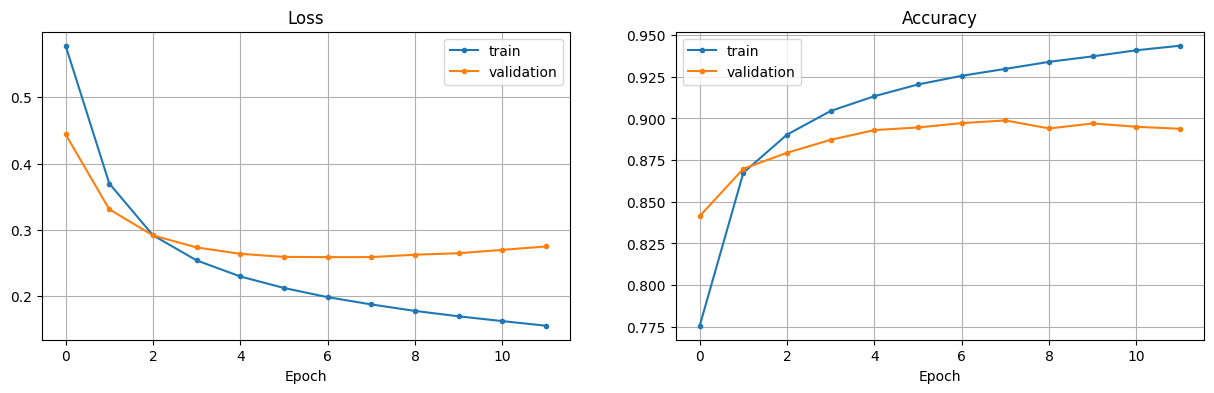

In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]

keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

best_model = build_rand_search_baseline_model(best_hp)
history = best_model.fit(
    train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    shuffle=False,
)

h = history.history
plot_loss_acc_per_ep(h["loss"], h["val_loss"],
                     h["binary_accuracy"], h["val_binary_accuracy"])

Best Epoch[7]: train_loss=0.1876  val_loss=0.2590  train_acc=0.9298  val_acc=0.8988

restoring the best model from the tuner + evaluation:

In [34]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

tuner = kt.RandomSearch(
    build_rand_search_baseline_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=15,
    directory="1_baseline_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,          # must be False, or it wipes the folder
)
tuner.reload()

best_baseline_model = tuner.get_best_models(1)[0]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_baseline_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

Reloading Tuner from 1_baseline_tuning\RNNs\tuner0.json
 9/79 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.8837 - loss: 0.2915

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - binary_accuracy: 0.8950 - loss: 0.2627

FINAL TEST ACCURACY: 89.50%
FINAL TEST LOSS:     0.2627


## Comparing architectures

### SimpleRNN

In [ ]:
def build_simple_rnn_model(spatial_dropout_rate: float, dropout_rate: float):
    return keras.Sequential([
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False),

        keras.layers.SpatialDropout1D(spatial_dropout_rate),
        keras.layers.SimpleRNN(units=NUM_UNITS),

        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

simple_rnn_model = build_simple_rnn_model(spatial_dropout_rate=0.0, dropout_rate=0.0)
simple_rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 300, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

- SGD showed itself too badly, we're not considering it
- we are fixing the unit count to 64 for a fair comparison across models
- because simple RNNs are incredible slow because they can't be parallelized on GPU. We know theoretically that they barely remember 10-20 timesteps, our `MAX_LENGTH` is 300. We therefore drastically decrease the number of options, epochs and patience. We just need a few numbers for the report to confirm.

In [24]:
def build_rand_search_simple_rnn_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.0, 0.1])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.0, 0.1])

    mdl = build_simple_rnn_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-3, 1e-2])
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_simple_rnn_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=10,
    directory="2_simple_rnn_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /2_simple_rnn_tuning/RNN
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 10 Complete [00h 15m 35s]
val_binary_accuracy: 0.73580002784729

Best val_binary_accuracy So Far: 0.868399977684021
Total elapsed time: 03h 14m 35s
{'dropout_rate': 0.0, 'spatial_dropout_rate': 0.0, 'lr': 0.001, 'optimizer': 'rmsprop'}


In [ ]:
debug_tuner(tuner)

,trial_id,score,best_epoch,dropout_rate,spatial_dropout_rate,lr,optimizer
5,05,0.8684,5,0.0,0.0,0.001,rmsprop
3,03,0.8622,2,0.1,0.0,0.001,rmsprop
6,06,0.8498,3,0.1,0.1,0.001,adam
0,00,0.8424,3,0.1,0.0,0.001,adam
2,02,0.7474,5,0.0,0.0,0.010,rmsprop
9,09,0.7358,2,0.1,0.1,0.010,adam
8,08,0.7280,3,0.0,0.1,0.010,adam
7,07,0.7252,6,0.0,0.1,0.010,rmsprop
1,01,0.7010,2,0.1,0.0,0.010,adam
4,04,0.6842,3,0.0,0.0,0.010,adam


restoring the best model manually (didn't save the tuning folder)

In [25]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

hp = kt.HyperParameters()
hp.Fixed("dropout_rate", 0.0)
hp.Fixed("spatial_dropout_rate", 0.0)
hp.Fixed("optimizer", "rmsprop")
hp.Fixed("lr", 0.001)

best_simple_rnn_model = build_rand_search_simple_rnn_model(hp)

history = best_simple_rnn_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 353s 565ms/step - binary_accuracy: 0.7040 - loss: 0.5578 - val_binary_accuracy: 0.8146 - val_loss: 0.4213
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 343s 548ms/step - binary_accuracy: 0.8399 - loss: 0.3895 - val_binary_accuracy: 0.7956 - val_loss: 0.4469
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 341s 545ms/step - binary_accuracy: 0.8675 - loss: 0.3232 - val_binary_accuracy: 0.8542 - val_loss: 0.3518
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 353s 564ms/step - binary_accuracy: 0.8741 - loss: 0.3171 - val_binary_accuracy: 0.8616 - val_loss: 0.3302
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 366s 586ms/step - binary_accuracy: 0.8904 - loss: 0.2830 - val_binary_accuracy: 0.8694 - val_loss: 0.3189
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 347s 555ms/step - binary_accuracy: 0.8939 - loss: 0.2681 - val_binary_accuracy: 0.8606 - val_loss: 0.3695
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 351s 561ms/step - binary_accuracy: 0.8875 - loss: 0.2815 - val_binary_accuracy: 0.85

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.5578  val_loss=0.4213  train_acc=0.7040  val_acc=0.8146
Epoch  1: train_loss=0.3895  val_loss=0.4469  train_acc=0.8399  val_acc=0.7956
Epoch  2: train_loss=0.3232  val_loss=0.3518  train_acc=0.8675  val_acc=0.8542
Epoch  3: train_loss=0.3171  val_loss=0.3302  train_acc=0.8741  val_acc=0.8616
Epoch  4: train_loss=0.2830  val_loss=0.3189  train_acc=0.8904  val_acc=0.8694
Epoch  5: train_loss=0.2681  val_loss=0.3695  train_acc=0.8939  val_acc=0.8606
Epoch  6: train_loss=0.2815  val_loss=0.4088  train_acc=0.8875  val_acc=0.8566



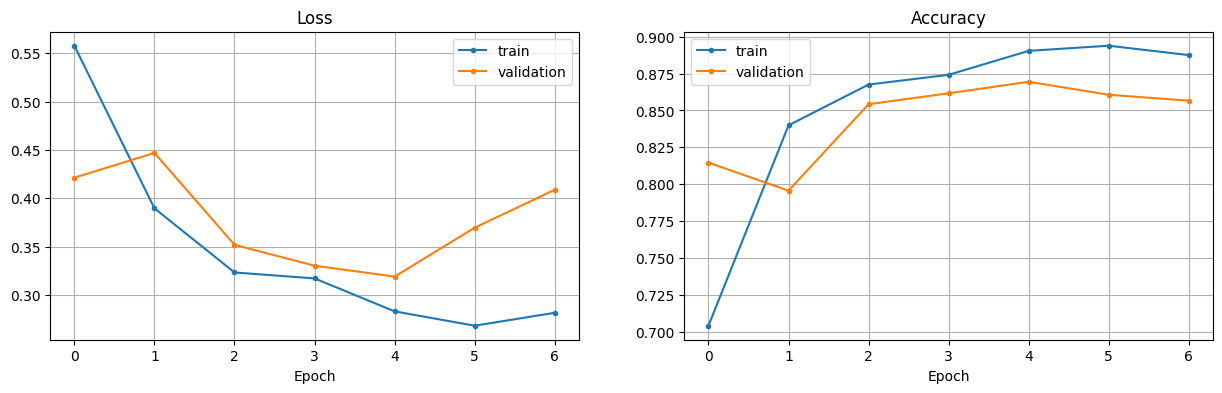

In [28]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["binary_accuracy"], history.history["val_binary_accuracy"])

In [29]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_simple_rnn_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 305ms/step - binary_accuracy: 0.8830 - loss: 0.3056

FINAL TEST ACCURACY: 88.30%
FINAL TEST LOSS:     0.3056


Even worse than logistic regression, must be the vanishing gradient problem that makes an impression of ordering not having any meaning in this task. Simple RNNs can't hold more than 10-20 steps to make a difference and they are terribly slow.

### LSTM

In [ ]:
def build_lstm_model(spatial_dropout_rate: float, dropout_rate: float):
    return keras.Sequential([
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False),

        keras.layers.SpatialDropout1D(spatial_dropout_rate),
        keras.layers.LSTM(units=NUM_UNITS),

        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

lstm_model = build_lstm_model(spatial_dropout_rate=0.0, dropout_rate=0.0)
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 300, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,897 (1.32 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
def build_rand_search_lstm_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.0, 0.1])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.0, 0.1])

    mdl = build_lstm_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-4, 1e-3, 1e-2])
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [31]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_lstm_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="3_lstm_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /RNNs/3_lstm_tuning/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 16 Complete [00h 01m 21s]
val_binary_accuracy: 0.9110000133514404

Best val_binary_accuracy So Far: 0.9110000133514404
Total elapsed time: 00h 32m 09s
{'dropout_rate': 0.1, 'spatial_dropout_rate': 0.1, 'lr': 0.01, 'optimizer': 'rmsprop'}


In [32]:
debug_tuner(tuner)

,trial_id,score,best_epoch,dropout_rate,spatial_dropout_rate,lr,optimizer
15,15,0.9110,3,0.1,0.1,0.0100,rmsprop
12,12,0.9106,3,0.1,0.0,0.0100,rmsprop
10,10,0.9088,3,0.0,0.1,0.0100,rmsprop
1,01,0.9072,4,0.0,0.0,0.0100,rmsprop
11,11,0.9048,2,0.0,0.1,0.0100,adam
6,06,0.9022,3,0.0,0.0,0.0100,adam
2,02,0.9008,2,0.1,0.0,0.0100,adam
14,14,0.8956,8,0.1,0.1,0.0010,rmsprop
5,05,0.8932,14,0.1,0.0,0.0001,rmsprop
7,07,0.8928,5,0.0,0.0,0.0010,rmsprop


the best is `15	15	0.9110	3	0.1	0.1	0.0100	rmsprop`

- regularization seems to have helped, adding more
- removing adam
- hold lr constant at 0.01
- increasing patience

In [40]:
def build_rand_search_lstm_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.2, 0.3, 0.4])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.2, 0.3, 0.4])

    mdl = build_lstm_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-2])

    mdl.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [41]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_lstm_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=9,
    directory="3_lstm_tuning_refined",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,                             # start with fresh folder in /RNNs/3_lstm_tuning_refined/ in order to be able to sample from the modified `build_rand_search_lstm_model`
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)], # more patience
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 9 Complete [00h 02m 32s]
val_binary_accuracy: 0.9110000133514404

Best val_binary_accuracy So Far: 0.9121999740600586
Total elapsed time: 00h 21m 26s
{'dropout_rate': 0.3, 'spatial_dropout_rate': 0.2, 'lr': 0.01}


In [42]:
debug_tuner(tuner)

,trial_id,score,best_epoch,dropout_rate,spatial_dropout_rate,lr
0,0,0.9122,3,0.3,0.2,0.01
7,7,0.9120,3,0.4,0.3,0.01
8,8,0.9110,5,0.3,0.4,0.01
1,1,0.9102,3,0.2,0.4,0.01
6,6,0.9096,6,0.4,0.4,0.01
3,3,0.9086,3,0.2,0.3,0.01
5,5,0.9086,3,0.2,0.2,0.01
4,4,0.9080,5,0.3,0.3,0.01
2,2,0.9078,5,0.4,0.2,0.01


We've only gained so much from additional dropout: 0.9110 -> 0.9122. We have been just extrapolating from noise, such insignificant difference is very unlikely comes from a 10% difference in the dropout probabilities. Just noise across runs, it wasn't the dropout effect.

restoring the best model from the tuner + evaluation:

In [47]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

tuner = kt.RandomSearch(
    build_rand_search_lstm_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=9,
    directory="3_lstm_tuning_refined",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,          # must be False, or it wipes the folder
)
tuner.reload()

best_lstm_model = tuner.get_best_models(1)[0]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_lstm_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

Reloading Tuner from 3_lstm_tuning_refined\RNNs\tuner0.json
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - binary_accuracy: 0.9088 - loss: 0.2415

FINAL TEST ACCURACY: 90.88%
FINAL TEST LOSS:     0.2415


### GRU

With constant BATCH_SIZE, EMBED_DIM, MAX_LENGTH, VOCAB_SIZE, NUM_UNITS.

| Architecture | Optimizer, lr | Regularization | Param_count | Training_time / ep | Best_epoch | Train_acc | Val_acc | Val_loss | Test_accuracy | Test_loss |
|--------------|---------------|----------------|-------------|--------------------|------------|------------|--------------|----------|---------------|-----------|





Selection was performed on validation. Test was evaluated once, after all choices were fixed.





Rung 3 — GRU(64). Expect roughly LSTM-level accuracy, faster. Report the time.

Rung 4 — Bidirectional(LSTM(64)) and, for fairness, Bidirectional(LSTM(37)).

Rung 5 — stacked: LSTM(64, return_sequences=True) → LSTM(32) (61,824 params). On 25,000 training reviews, expect this to not help — and be ready to report that as a finding rather than a failure. Check the train/val gap to show it's overfitting, not underfitting.